In [ ]:
!gdown --id 1J74ocROmNXQYXDB1sVOkJfSOK7v3RnzS
!unzip shobdotori.zip -d /content/shobdotori

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1J74ocROmNXQYXDB1sVOkJfSOK7v3RnzS
From (redirected): https://drive.google.com/uc?id=1J74ocROmNXQYXDB1sVOkJfSOK7v3RnzS&confirm=t&uuid=59ec6fd9-3f2b-48b9-95ba-242de7ed5690
To: /content/shobdotori.zip
100% 352M/352M [00:06<00:00, 58.2MB/s]
Archive:  shobdotori.zip
  inflating: /content/shobdotori/Test/test_001.wav  
  inflating: /content/shobdotori/Test/test_002.wav  
  inflating: /content/shobdotori/Test/test_003.wav  
  inflating: /content/shobdotori/Test/test_004.wav  
  inflating: /content/shobdotori/Test/test_005.wav  
  inflating: /content/shobdotori/Test/test_006.wav  
  inflating: /content/shobdotori/Test/test_007.wav  
  inflating: /content/shobdotori/Test/test_008.wav  
  inflating: /content/shobdoto

### Transformer upgrade (HF 404 client error)

In [ ]:
!pip install -U transformers

# Import Necessary Libraries

In [ ]:
# Bangla ASR – Whisper (bangla-speech-processing/BanglaASR)
import os
import numpy as np
import pandas as pd
import csv
import torch
import librosa
from pathlib import Path
from transformers import WhisperProcessor, WhisperForConditionalGeneration

# Necessary CONFIG

In [ ]:
MODEL_ID = "bangla-speech-processing/BanglaASR"
CACHE_DIR = "./hf_cache"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_dir = Path("/content/Train")
test_dir = Path("/content/Test")
train_annot = Path("/content/Train_annotation")

# EDA

Distribution of audio files per dialect in Training set:
  Brahmanbaria: 107 files
  Noakhali: 61 files
  Kushtia: 53 files
  Rajshahi: 73 files
  Pabna: 166 files
  Jhenaidah: 270 files
  Khulna: 21 files
  Lakshmipur: 400 files
  Jessore: 33 files
  Bogura: 114 files
  Chittagong: 401 files
  Feni: 66 files
  Mymensingh: 400 files
  Barisal: 39 files
  Bhola: 189 files
  Sylhet: 324 files
  Natore: 108 files
  Comilla: 53 files
  Dhaka: 115 files
  Rangpur: 357 files


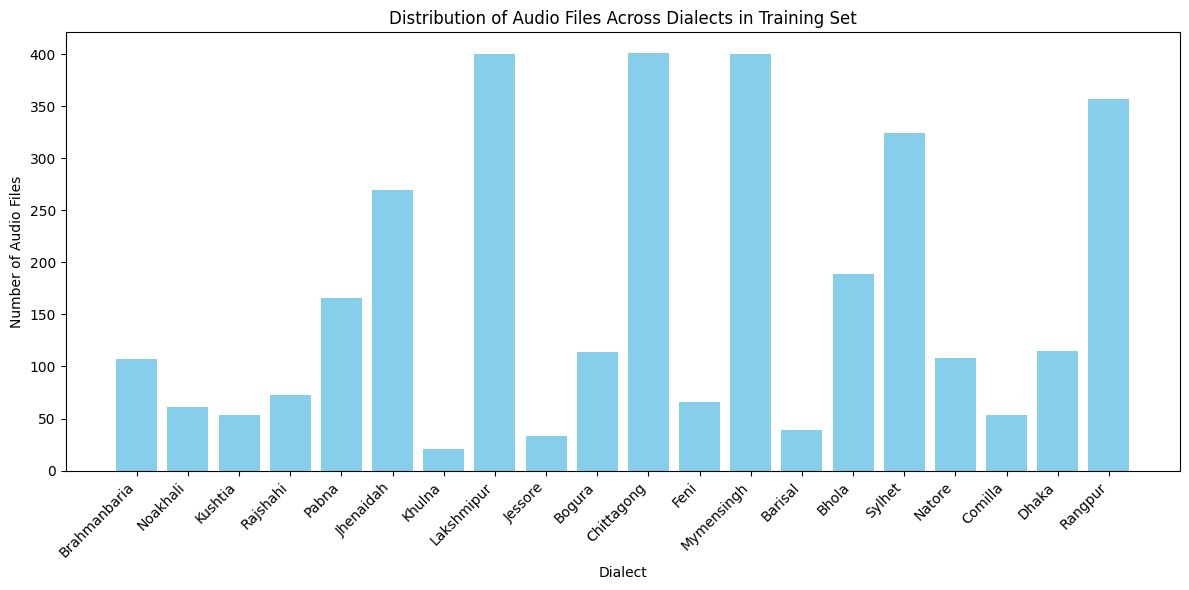

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

def get_dialect_distribution(base_dir):
    dialect_counts = Counter()
    for dialect_dir in base_dir.iterdir():
        if dialect_dir.is_dir():
            wav_files_count = len(list(dialect_dir.glob("*.wav")))
            dialect_counts[dialect_dir.name] = wav_files_count
    return dialect_counts

train_dialect_distribution = get_dialect_distribution(train_dir)

print("Distribution of audio files per dialect in Training set:")
for dialect, count in train_dialect_distribution.items():
    print(f"  {dialect}: {count} files")

# Visualize the distribution
dialects = list(train_dialect_distribution.keys())
counts = list(train_dialect_distribution.values())

plt.figure(figsize=(12, 6))
plt.bar(dialects, counts, color='skyblue')
plt.xlabel('Dialect')
plt.ylabel('Number of Audio Files')
plt.title('Distribution of Audio Files Across Dialects in Training Set')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
total_duration_per_dialect = {}

for dialect_dir in train_dir.iterdir():
    if dialect_dir.is_dir():
        dialect_name = dialect_dir.name
        total_duration_seconds = 0
        for wav_file in dialect_dir.glob("*.wav"):
            try:
                duration = librosa.get_duration(path=str(wav_file))
                total_duration_seconds += duration
            except Exception as e:
                print(f"Error getting duration for {wav_file}: {e}")
        total_duration_per_dialect[dialect_name] = total_duration_seconds

print("Total audio duration per dialect in Training set:")
for dialect, duration_seconds in total_duration_per_dialect.items():
    duration_minutes = duration_seconds / 60
    duration_hours = duration_seconds / 3600
    print(f"  {dialect}: {duration_seconds:.2f} seconds ({duration_minutes:.2f} minutes, {duration_hours:.2f} hours)")

Total audio duration per dialect in Training set:
  Brahmanbaria: 505.68 seconds (8.43 minutes, 0.14 hours)
  Noakhali: 259.86 seconds (4.33 minutes, 0.07 hours)
  Kushtia: 149.16 seconds (2.49 minutes, 0.04 hours)
  Rajshahi: 389.22 seconds (6.49 minutes, 0.11 hours)
  Pabna: 608.28 seconds (10.14 minutes, 0.17 hours)
  Jhenaidah: 912.90 seconds (15.21 minutes, 0.25 hours)
  Khulna: 117.57 seconds (1.96 minutes, 0.03 hours)
  Lakshmipur: 1806.36 seconds (30.11 minutes, 0.50 hours)
  Jessore: 106.38 seconds (1.77 minutes, 0.03 hours)
  Bogura: 607.14 seconds (10.12 minutes, 0.17 hours)
  Chittagong: 1543.72 seconds (25.73 minutes, 0.43 hours)
  Feni: 268.65 seconds (4.48 minutes, 0.07 hours)
  Mymensingh: 1452.96 seconds (24.22 minutes, 0.40 hours)
  Barisal: 238.74 seconds (3.98 minutes, 0.07 hours)
  Bhola: 705.60 seconds (11.76 minutes, 0.20 hours)
  Sylhet: 1415.06 seconds (23.58 minutes, 0.39 hours)
  Natore: 604.50 seconds (10.07 minutes, 0.17 hours)
  Comilla: 158.88 seconds (2.

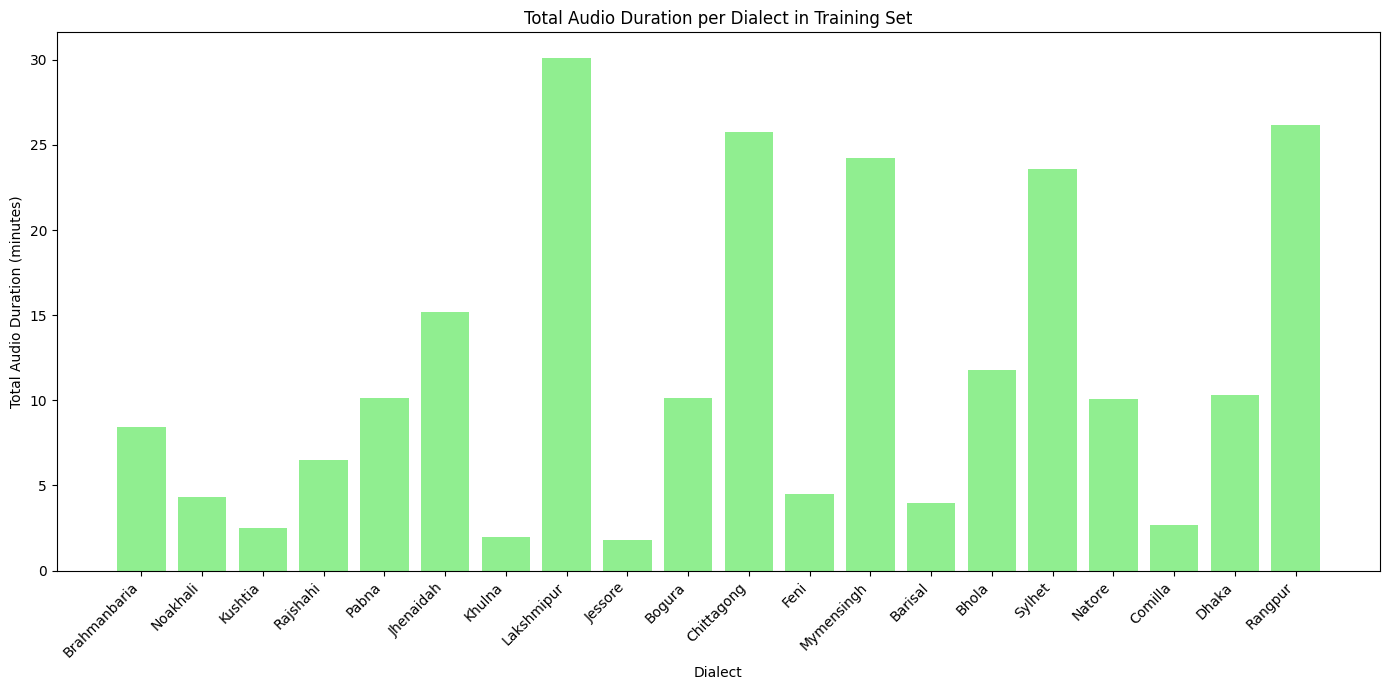

In [ ]:
dialects_duration = list(total_duration_per_dialect.keys())
durations_seconds = list(total_duration_per_dialect.values())
durations_minutes = [d / 60 for d in durations_seconds]

plt.figure(figsize=(14, 7))
plt.bar(dialects_duration, durations_minutes, color='lightgreen')
plt.xlabel('Dialect')
plt.ylabel('Total Audio Duration (minutes)')
plt.title('Total Audio Duration per Dialect in Training Set')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Average Duration per Dialect


In [ ]:
average_duration_per_dialect = {}
for dialect, total_duration in total_duration_per_dialect.items():
    file_count = train_dialect_distribution.get(dialect, 0)
    if file_count > 0:
        average_duration_per_dialect[dialect] = total_duration / file_count
    else:
        average_duration_per_dialect[dialect] = 0 # Handle cases with no files to avoid division by zero

print("Average audio duration per dialect in Training set:")
for dialect, avg_duration_seconds in average_duration_per_dialect.items():
    print(f"  {dialect}: {avg_duration_seconds:.2f} seconds")

Average audio duration per dialect in Training set:
  Brahmanbaria: 4.73 seconds
  Noakhali: 4.26 seconds
  Kushtia: 2.81 seconds
  Rajshahi: 5.33 seconds
  Pabna: 3.66 seconds
  Jhenaidah: 3.38 seconds
  Khulna: 5.60 seconds
  Lakshmipur: 4.52 seconds
  Jessore: 3.22 seconds
  Bogura: 5.33 seconds
  Chittagong: 3.85 seconds
  Feni: 4.07 seconds
  Mymensingh: 3.63 seconds
  Barisal: 6.12 seconds
  Bhola: 3.73 seconds
  Sylhet: 4.37 seconds
  Natore: 5.60 seconds
  Comilla: 3.00 seconds
  Dhaka: 5.37 seconds
  Rangpur: 4.39 seconds


## Calculated average audio duration per dialect

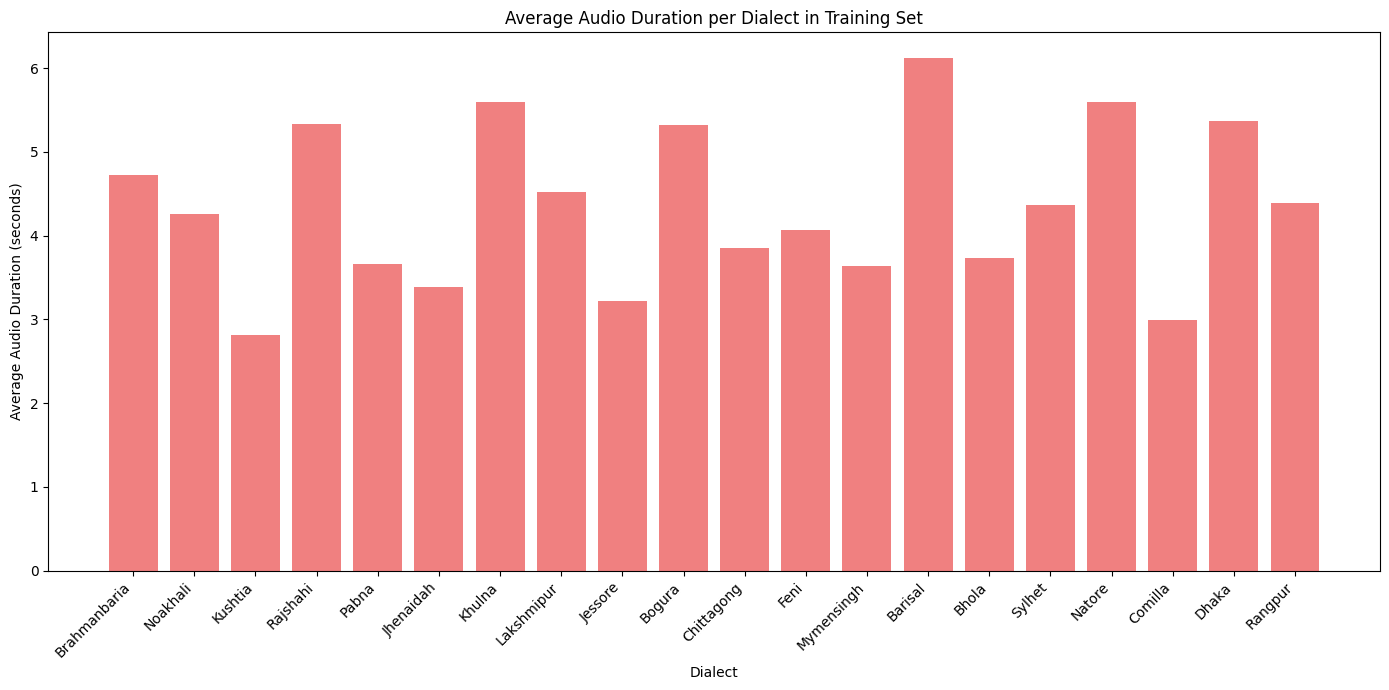

In [ ]:
dialects_avg = list(average_duration_per_dialect.keys())
avg_durations = list(average_duration_per_dialect.values())

plt.figure(figsize=(14, 7))
plt.bar(dialects_avg, avg_durations, color='lightcoral')
plt.xlabel('Dialect')
plt.ylabel('Average Audio Duration (seconds)')
plt.title('Average Audio Duration per Dialect in Training Set')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Coefficient of Variation (CV) for both the number of files and the total duration per dialect


In [ ]:
import numpy as np

# Calculate CV for number of files per dialect
counts_array = np.array(list(train_dialect_distribution.values()))
mean_counts = np.mean(counts_array)
std_counts = np.std(counts_array)

cv_counts = (std_counts / mean_counts) * 100 if mean_counts > 0 else 0
print(f"Coefficient of Variation for Number of Files per Dialect: {cv_counts:.2f}%")

# Calculate CV for total duration per dialect
durations_array = np.array(list(total_duration_per_dialect.values()))
mean_durations = np.mean(durations_array)
std_durations = np.std(durations_array)

cv_durations = (std_durations / mean_durations) * 100 if mean_durations > 0 else 0
print(f"Coefficient of Variation for Total Duration per Dialect: {cv_durations:.2f}%")

Coefficient of Variation for Number of Files per Dialect: 80.06%
Coefficient of Variation for Total Duration per Dialect: 77.13%


Individual audio file durations through each dialect directory and using `librosa.get_duration`



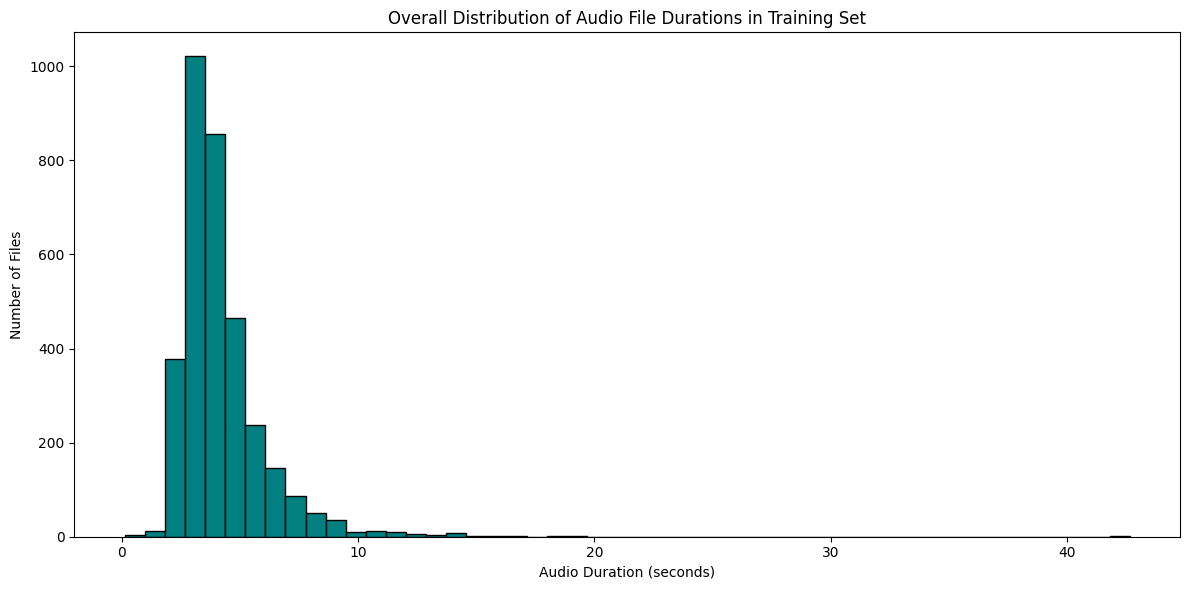

In [ ]:
all_durations = []

for dialect_dir in train_dir.iterdir():
    if dialect_dir.is_dir():
        for wav_file in dialect_dir.glob("*.wav"):
            try:
                duration = librosa.get_duration(path=str(wav_file))
                all_durations.append(duration)
            except Exception as e:
                print(f"Error getting duration for {wav_file}: {e}")

plt.figure(figsize=(12, 6))
plt.hist(all_durations, bins=50, color='teal', edgecolor='black')
plt.xlabel('Audio Duration (seconds)')
plt.ylabel('Number of Files')
plt.title('Overall Distribution of Audio File Durations in Training Set')
plt.tight_layout()
plt.show()


## Summary of Findings

TheThe EDA for the audio dataset revealed several key aspects of its distribution and heterogeneity:

1.  **Distribution of Audio Files per Dialect**: The number of audio files varied significantly across dialects in the training set. For instance, `Lakshmipur` and `Mymensingh` had 400 files each, while `Khulna` had only 21 files. This suggests an imbalanced dataset in terms of file counts per dialect.

2.  **Total Audio Duration per Dialect**: Similar to file counts, the total duration of audio varied widely. `Lakshmipur` had the highest total duration (approx. 30.11 minutes), whereas `Jessore` had one of the lowest (approx. 1.77 minutes). This further emphasizes the imbalance.

3.  **Average Audio Duration per Dialect**: The average duration of individual audio files also showed some variation, ranging from approximately 2.81 seconds (Kushtia) to 6.12 seconds (Barisal). While some dialects had longer average recordings, others had shorter ones, indicating potential differences in recording practices or content per dialect.

4.  **Coefficient of Variation (CV)**:
    *   **CV for Number of Files per Dialect**: `80.06%`.
    *   **CV for Total Duration per Dialect**: `77.13%`.
    These high Coefficient of Variation values (both above 75%) confirm a substantial degree of heterogeneity in the dataset regarding both the number of samples and the total recording time across different dialects. This means that the dataset is not uniformly distributed, and some dialects are significantly over-represented or under-represented compared to others.

5.  **Overall Distribution of Audio File Durations (Histogram)**: The histogram of all audio file durations provides a holistic view. It likely shows that the majority of audio files are relatively short (e.g., concentrated in the 0-10 second range), with fewer files having longer durations. This is typical for speech datasets where individual utterances are often brief.

The dataset exhibits considerable heterogeneity across dialects in terms of file counts, total duration, and average duration. The high Coefficients of Variation highlight this imbalance, which is an important factor to consider during model training to avoid bias towards dominant dialects or to apply sampling strategies to mitigate the imbalance.

### Data Analysis Key Findings
*   The average audio duration per dialect in the training set varied, ranging from approximately 2.81 seconds (Kushtia) to 6.12 seconds (Barisal), indicating differences in recording lengths across dialects.
*   The Coefficient of Variation (CV) for the number of files per dialect is 80.06%, and for the total duration per dialect is 77.13%. Both values being above 75% confirm significant heterogeneity and imbalance in the dataset regarding sample counts and total recording time across different dialects.
*   The distribution of audio files per dialect is highly imbalanced, with some dialects like Lakshmipur and Mymensingh having 400 files each, while others like Khulna have only 21 files.
*   Similarly, total audio duration per dialect is imbalanced; for example, Lakshmipur has approximately 30.11 minutes of audio, contrasting with Jessore's approximately 1.77 minutes.
*   The overall distribution of audio file durations indicates that the majority of audio files are relatively short (likely concentrated in the 0-10 second range), with fewer files having longer durations.

### Insights or Next Steps
*   The observed significant heterogeneity in file counts and total duration across dialects suggests that direct use of this dataset for model training without addressing the imbalance could lead to bias towards over-represented dialects.
*   Future steps should include implementing strategies such as resampling (e.g., oversampling minority classes or undersampling majority classes), data augmentation for under-represented dialects, or using weighted loss functions during model training to mitigate the effects of this imbalance.


# Load Model (BanglaASR)

In [ ]:
def load_model():
    print("Loading model and processor...")
    processor = WhisperProcessor.from_pretrained(MODEL_ID, cache_dir=CACHE_DIR)
    model = WhisperForConditionalGeneration.from_pretrained(MODEL_ID, cache_dir=CACHE_DIR).to(DEVICE)
    model.eval()
    print(f"Model loaded on {DEVICE}")
    return processor, model

In [ ]:
processor, model = load_model()

Loading model and processor...
Model loaded on cuda


# Transcribe audio to text

In [ ]:
def transcribe(wav_path: str) -> str:
    try:
        # Load and resample
        speech, sr = librosa.load(wav_path, sr=None, mono=True)
        if sr != 16_000:
            speech = librosa.resample(speech, orig_sr=sr, target_sr=16_000)

        # Feature extraction
        input_features = processor.feature_extractor(
            speech, sampling_rate=16_000, return_tensors="pt"
        ).input_features.to(DEVICE)

        # Generate
        with torch.no_grad():
            predicted_ids = model.generate(input_features, max_length=225)

        # Decode
        return processor.decode(predicted_ids[0], skip_special_tokens=True)
    except Exception as e:
        print(f"Error transcribing {wav_path}: {e}")
        return ""  # fallback

# Submission

In [ ]:
if __name__ == "__main__":
    test_dir = Path("/kaggle/input/shobdotori/Test")
    if not test_dir.exists():
        print(f"Test directory not found: {test_dir}")
        exit(1)

    submission_path = "submission.csv"
    wav_files = sorted(test_dir.glob("*.wav"))
    print(f"Found {len(wav_files)} test files")

    with open(submission_path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f, quoting=csv.QUOTE_MINIMAL)
        writer.writerow(["audio", "text"])  # header

        for wav_file in wav_files:
            txt = transcribe(str(wav_file))
            writer.writerow([wav_file.name, txt])
            print(f"{wav_file.name} -> {txt}")

    print(f"Submission saved to {submission_path} (CSV-safe)")

Found 450 test files
test_001.wav -> তু কিছেল পড়া বি-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
test_002.wav -> তুমি আমারে কলম্ডা দিবানি।
test_003.wav -> আইস্কেট দুপরি রাস্তায় পানি জমিলো।
test_004.wav -> আইসকেশ শহকালে হঠাৎ বৃষ্টি না মিল।
test_005.wav -> তুকিও ফরতুল বি-
test_006.wav -> একি ফোন দরবে নি।
test_007.wav -> আইজকে দওয়ার মেঘজম ছে।
test_008.wav -> আর সোরো বাই স্কুলে যার।
test_009.wav -> আম গান মেক্সি আইজ।
test_010.wav -> তুমি কি আইজ বন্ধুর সাথে দেখা হরসেও?
test_011.wav -> দুই ওয়ার্কেন, আস্তাহাস্তায় বন্ধ করিতে।
test_012.wav -> আমি আয়েজ নতুন যুতা কিনিসি?
test_013.wav -> তুমি কে আজ অফিসের জাভা?
test_014.wav -> মইশ হকালেন নাস্তার ডেম খায়জম।
test_015.wav -> রাজদ্ববীরে জরিত রাস্তার আভিসিল।
test_016.wav -> আমিয়ের বিকালে আটায্যায় যাইতে সাই।
test_017.wav -> আমাগু স্কুল আজ বিষয়কমষ্ট্র নৈড়িয়।
test_018.wav -> আই পাধত্যা না মানসি।
tes

# Pre-processing

## Augmentation

Under-represented dialects: `Khulna, Jessore, Kushtia, Comilla, Noakhali, Barisal, Feni, Rajshahi, Brahmanbaria, and Natore.`

In [ ]:
under_represented_dialects = [
    "Khulna", "Jessore", "Kushtia", "Comilla", "Noakhali",
    "Barisal", "Feni", "Rajshahi", "Brahmanbaria", "Natore"
]

print(f"Under-represented dialects identified: {under_represented_dialects}")

Under-represented dialects identified: ['Khulna', 'Jessore', 'Kushtia', 'Comilla', 'Noakhali', 'Barisal', 'Feni', 'Rajshahi', 'Brahmanbaria', 'Natore']


### Implement Pitch Shifting


In [ ]:
import soundfile as sf
import librosa
import os

def pitch_shift_audio(audio_path: str, output_path: str, n_steps: float):
    """
    Performs pitch shifting on an audio file and saves the augmented audio.

    Args:
        audio_path (str): Path to the input audio file.
        output_path (str): Path to save the pitch-shifted audio file.
        n_steps (float): The amount to shift pitch by (in semitones).
    """
    try:
        # Load audio with original sampling rate
        speech, sr = librosa.load(audio_path, sr=None, mono=True)

        # Apply pitch shifting
        pitched_speech = librosa.effects.pitch_shift(y=speech, sr=sr, n_steps=n_steps)

        # Save the augmented audio
        sf.write(output_path, pitched_speech, sr, subtype='PCM_16')
        print(f"Successfully pitch-shifted '{audio_path}' by {n_steps} semitones to '{output_path}'")

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
